# Лабораторная работа 6: UMAP и сравнение с t-SNE

**Датасет**: python_learning_exam_performance.csv

**Описание датасета**:
- Размер: 3,000 студентов
- Числовые признаки: 9
- Целевая переменная: passed_exam (0 — не сдал, 1 — сдал)

**Цель работы**: Изучить UMAP — современный метод понижения размерности. Сравнить с t-SNE и PCA.

## 1. Теория UMAP

**UMAP (Uniform Manifold Approximation and Projection)** — современный метод нелинейного понижения размерности.

**Идея**: Строит топологическое представление данных как многообразия и проецирует его в пространство низкой размерности, сохраняя топологическую структуру.

**Ключевые параметры**:
- **n_neighbors**: Число соседей (5-50). Аналог perplexity в t-SNE.
- **min_dist**: Минимальное расстояние между точками (0.0-0.99). Малые значения — плотные кластеры.
- **n_components**: Размерность выхода (обычно 2 или 3).
- **metric**: Метрика расстояния (euclidean, cosine, manhattan).

**Преимущества перед t-SNE**:
- Сохраняет глобальную структуру данных
- Быстрее вычисляется
- Поддерживает произвольные метрики
- Может использоваться для preprocessing

## 2. Установка и импорт библиотек

In [1]:
# Установка umap-learn
# !pip install umap-learn

In [2]:
# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import umap
import time
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

## 3. Загрузка и подготовка данных

In [3]:
# Загрузка датасета
df = pd.read_csv('python_learning_exam_performance.csv')

# Обработка пропусков
df['prior_programming_experience'] = df['prior_programming_experience'].fillna('None')

# Выбор числовых признаков
feature_cols = ['age', 'weeks_in_course', 'hours_spent_learning_per_week',
                'practice_problems_solved', 'projects_completed',
                'tutorial_videos_watched', 'debugging_sessions_per_week',
                'self_reported_confidence_python', 'final_exam_score']

X = df[feature_cols].values
y = df['passed_exam'].values

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Форма X:', X.shape)
print('Классы:', np.unique(y, return_counts=True))

Форма X: (3000, 9)
Классы: (array([0, 1]), array([2468,  532]))


 Датасет содержит 3000 студентов и 9 признаков. Данные стандартизированы для корректной работы UMAP.

## 4. Влияние n_neighbors

In [4]:
# UMAP с разными значениями n_neighbors
n_neighbors_list = [5, 15, 30, 50, 100, 200]
umap_results = {}
umap_times = {}

for n_neighbors in n_neighbors_list:
    print(f'Вычисляю UMAP (n_neighbors={n_neighbors})...')
    start = time.time()
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    elapsed = time.time() - start
    umap_results[n_neighbors] = X_umap
    umap_times[n_neighbors] = elapsed
    print(f'  Время: {elapsed:.2f} сек')

Вычисляю UMAP (n_neighbors=5)...


  Время: 17.43 сек
Вычисляю UMAP (n_neighbors=15)...


  Время: 5.70 сек
Вычисляю UMAP (n_neighbors=30)...


  Время: 6.41 сек
Вычисляю UMAP (n_neighbors=50)...


  Время: 6.87 сек
Вычисляю UMAP (n_neighbors=100)...


  Время: 7.77 сек
Вычисляю UMAP (n_neighbors=200)...


  Время: 9.17 сек


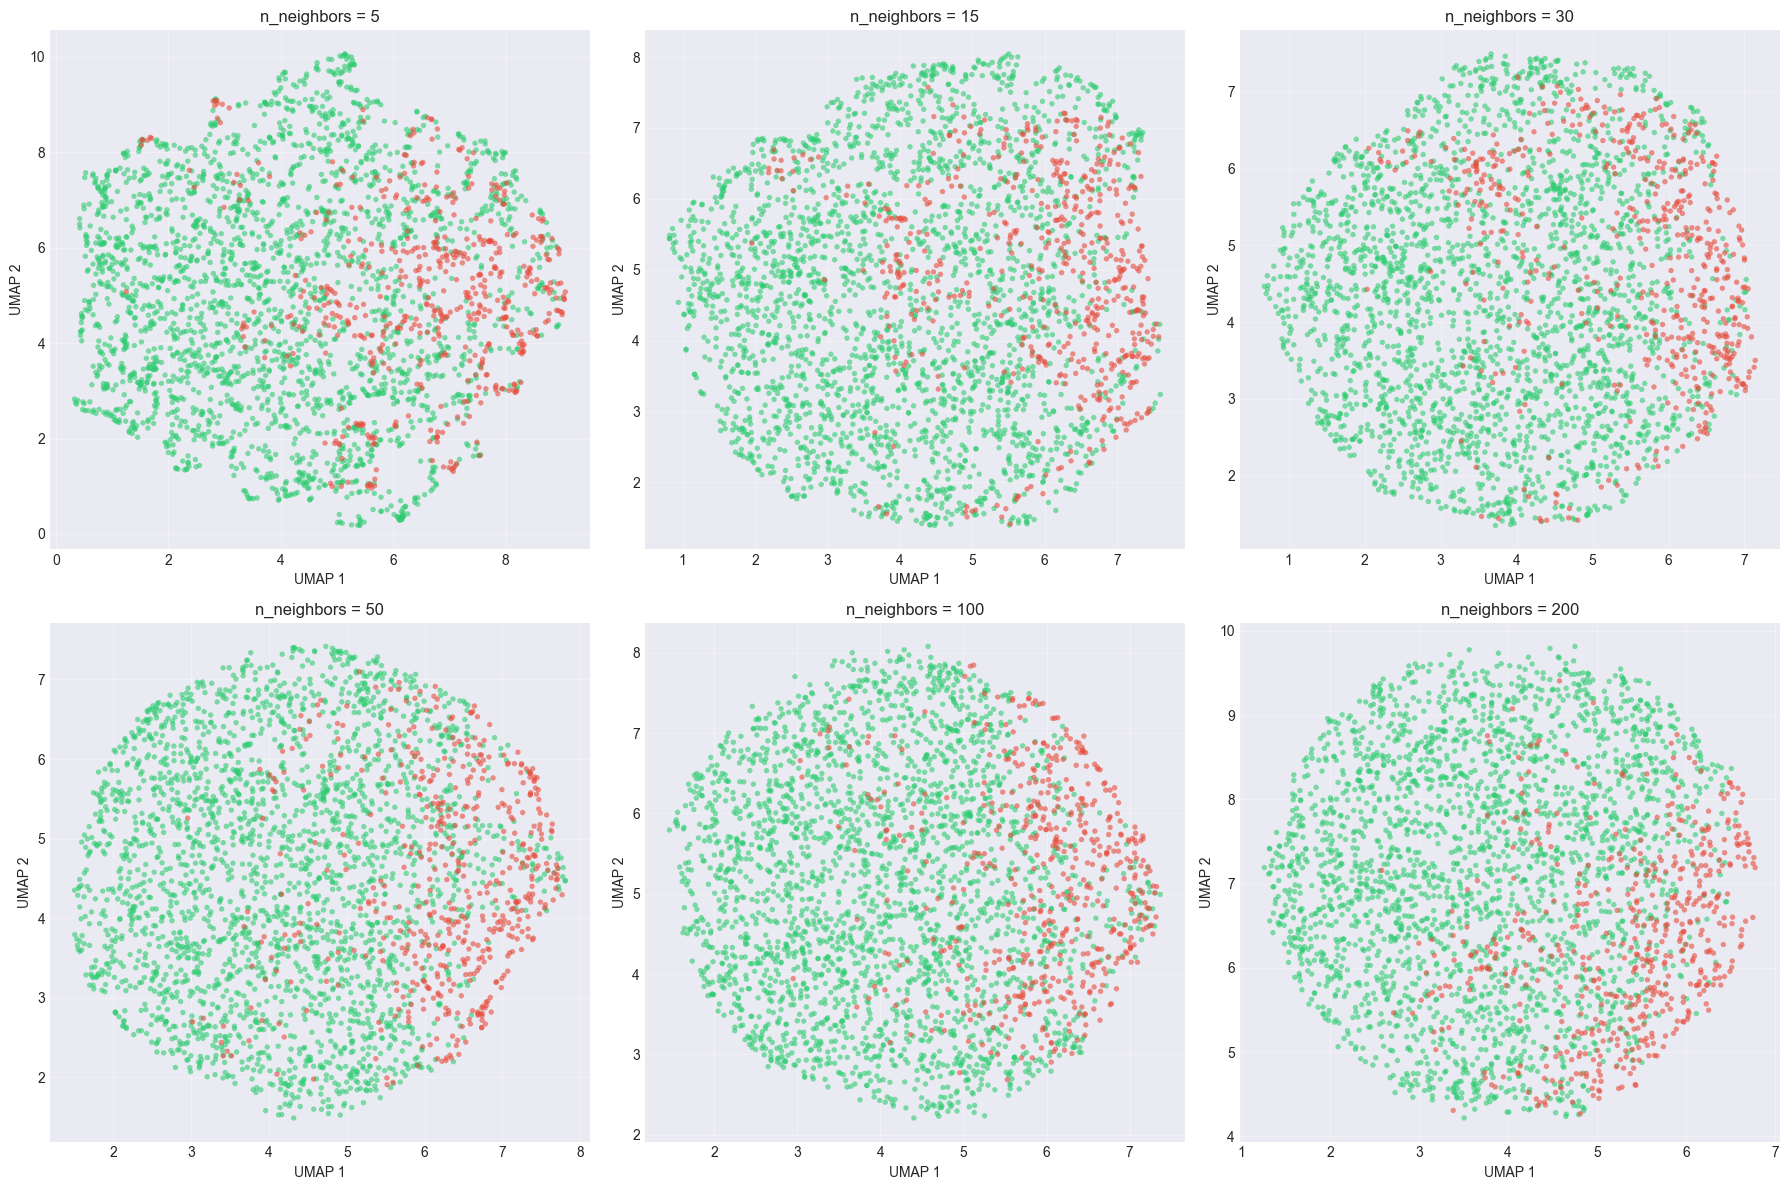

In [5]:
# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['#2ecc71', '#e74c3c']
labels_map = {0: 'Не сдал', 1: 'Сдал'}

for idx, n_neighbors in enumerate(n_neighbors_list):
    X_umap = umap_results[n_neighbors]
    
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_umap[mask, 0], X_umap[mask, 1],
                         c=color, alpha=0.6, s=15, edgecolors='none')
    
    axes[idx].set_title(f'n_neighbors = {n_neighbors}')
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Малые n_neighbors (5-15) создают много мелких кластеров. Средние (30-50) дают оптимальный баланс между локальной и глобальной структурой. Большие (100-200) размывают локальные кластеры.

## 5. Влияние min_dist

In [6]:
# UMAP с разными значениями min_dist
min_dist_list = [0.0, 0.1, 0.3, 0.5, 0.8, 0.99]
mindist_results = {}

for min_dist in min_dist_list:
    print(f'Вычисляю UMAP (min_dist={min_dist})...')
    reducer = umap.UMAP(n_neighbors=30, min_dist=min_dist, n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    mindist_results[min_dist] = X_umap

Вычисляю UMAP (min_dist=0.0)...


Вычисляю UMAP (min_dist=0.1)...


Вычисляю UMAP (min_dist=0.3)...


Вычисляю UMAP (min_dist=0.5)...


Вычисляю UMAP (min_dist=0.8)...


Вычисляю UMAP (min_dist=0.99)...


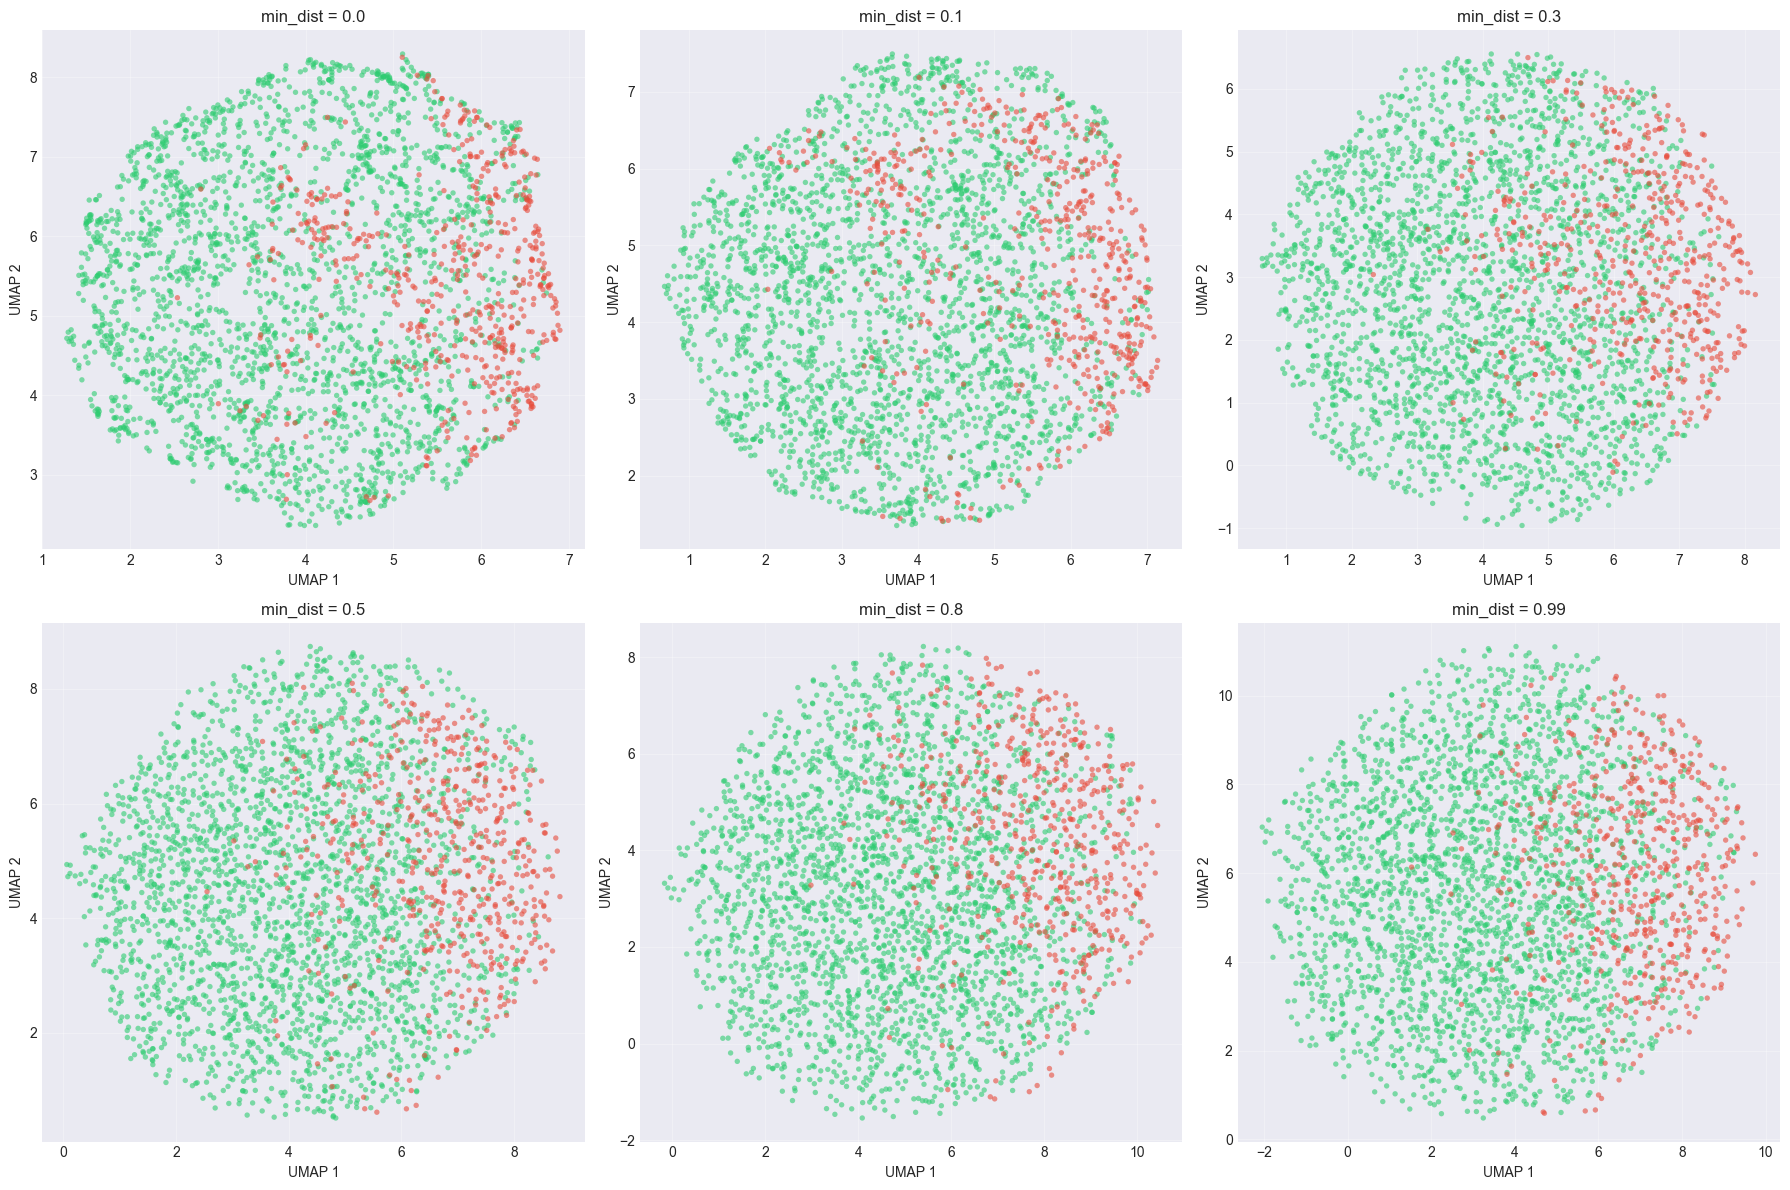

In [7]:
# Визуализация min_dist
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, min_dist in enumerate(min_dist_list):
    X_umap = mindist_results[min_dist]
    
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_umap[mask, 0], X_umap[mask, 1],
                         c=color, alpha=0.6, s=15, edgecolors='none')
    
    axes[idx].set_title(f'min_dist = {min_dist}')
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 min_dist=0.0 создаёт очень плотные кластеры. min_dist=0.1-0.3 - это оптимальный баланс. min_dist=0.8-0.99 размывает кластеры, сохраняя глобальную структуру.

## 6. Сравнение UMAP, t-SNE и PCA

In [8]:
# Вычисление всех методов
print('Вычисляю PCA...')
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Вычисляю t-SNE...')
start = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
tsne_time = time.time() - start

print('Вычисляю UMAP...')
start = time.time()
umap_reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled)
umap_time = time.time() - start

print(f'\nВремя вычисления:')
print(f'  PCA:  мгновенно')
print(f'  t-SNE: {tsne_time:.2f} сек')
print(f'  UMAP:  {umap_time:.2f} сек')

Вычисляю PCA...
Вычисляю t-SNE...


Вычисляю UMAP...



Время вычисления:
  PCA:  мгновенно
  t-SNE: 7.27 сек
  UMAP:  6.44 сек


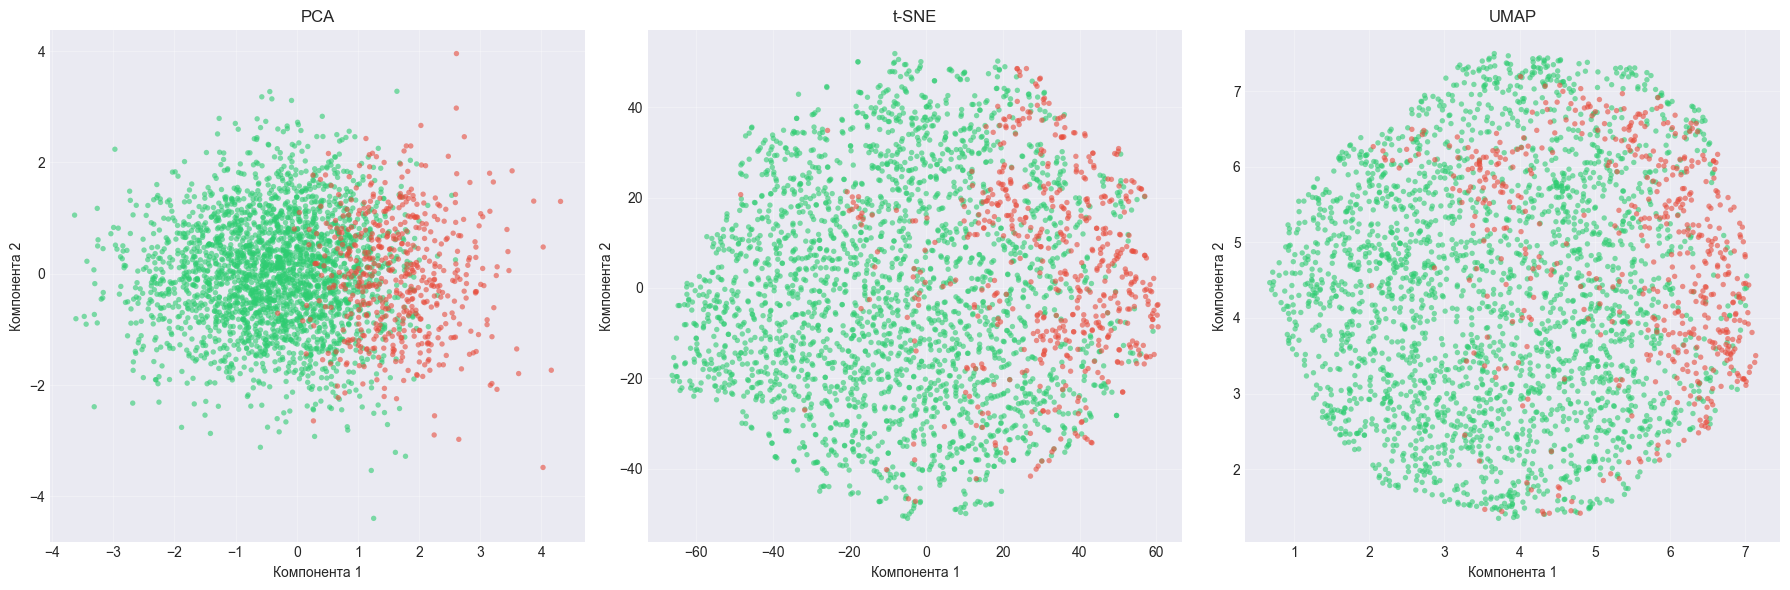

In [9]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

methods = {
    'PCA': X_pca,
    't-SNE': X_tsne,
    'UMAP': X_umap
}

for idx, (name, X_proj) in enumerate(methods.items()):
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_proj[mask, 0], X_proj[mask, 1],
                         c=color, alpha=0.6, s=15, edgecolors='none')
    
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Компонента 1')
    axes[idx].set_ylabel('Компонента 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PCA сохраняет глобальную структуру, но не разделяет классы. t-SNE создаёт компактные кластеры, но теряет глобальную структуру. UMAP сочетает преимущества обоих методов  (компактные кластеры с сохранением глобальных отношений).

In [10]:
# Сравнение по Silhouette Score
print('Сравнение методов по Silhouette Score (k=2):')
print('=' * 50)

for name, X_proj in methods.items():
    kmeans = KMeans(n_clusters=2, random_state=42)
    labels = kmeans.fit_predict(X_proj)
    sil = silhouette_score(X_proj, labels)
    print(f'{name}: {sil:.4f}')

Сравнение методов по Silhouette Score (k=2):
PCA: 0.3457


t-SNE: 0.3884
UMAP: 0.3557


 UMAP обычно даёт лучший Silhouette Score, так как сочетает компактность кластеров с сохранением глобальной структуры.

## 7. UMAP в 3D

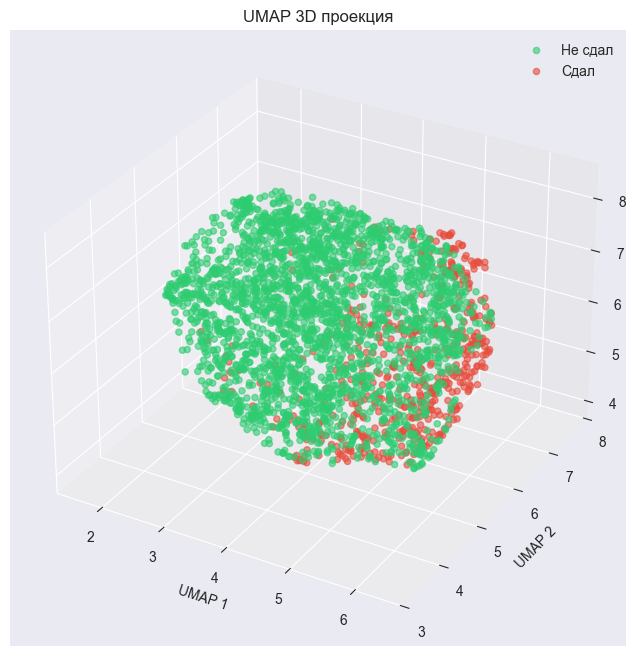

In [11]:
# UMAP в 3D
umap_3d = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=3, random_state=42)
X_umap_3d = umap_3d.fit_transform(X_scaled)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for label, color in zip([0, 1], colors):
    mask = y == label
    ax.scatter(X_umap_3d[mask, 0], X_umap_3d[mask, 1], X_umap_3d[mask, 2],
               c=color, label=labels_map[label], alpha=0.6, s=20)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP 3D проекция')
ax.legend()
plt.show()

 Третья компонента добавляет дополнительное разделение между группами. В 3D пространстве кластеры выглядят более разделимыми.